# Image Denoising using Autoencoder on MNIST Dataset

## Week 6 Assessment

### Objective
To build a Deep Learning Autoencoder that removes noise from handwritten digit images using the MNIST dataset.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model

In [17]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)


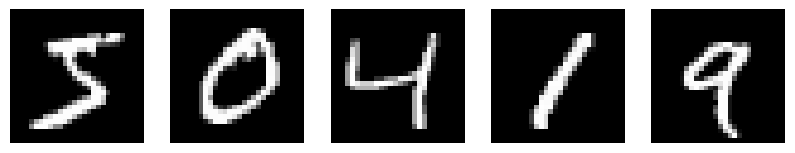

In [18]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

In [19]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print("Maximum Pixel Value :", x_train.max())
print("Minimum Pixel Value :", x_train.min())

Maximum Pixel Value : 1.0
Minimum Pixel Value : 0.0


In [20]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

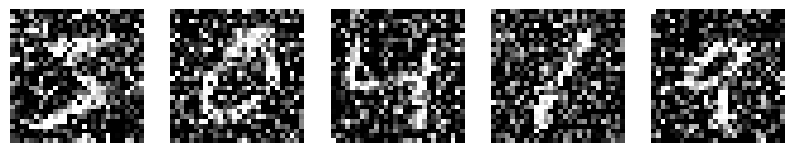

In [21]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i], cmap='gray')
    plt.axis('off')

plt.show()

In [22]:
x_train = x_train.reshape((len(x_train),784))
x_test = x_test.reshape((len(x_test),784))

x_train_noisy = x_train_noisy.reshape((len(x_train_noisy),784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy),784))

print(x_train.shape)

(60000, 784)


In [23]:
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)

In [24]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [26]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2437 - val_loss: 0.1774
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1618 - val_loss: 0.1485
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1437 - val_loss: 0.1378
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1356 - val_loss: 0.1316
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1307 - val_loss: 0.1283
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1273 - val_loss: 0.1254
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1247 - val_loss: 0.1231
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1227 - val_loss: 0.1211
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1210 - val_loss: 0.1201
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1196 - val_loss: 0.1193


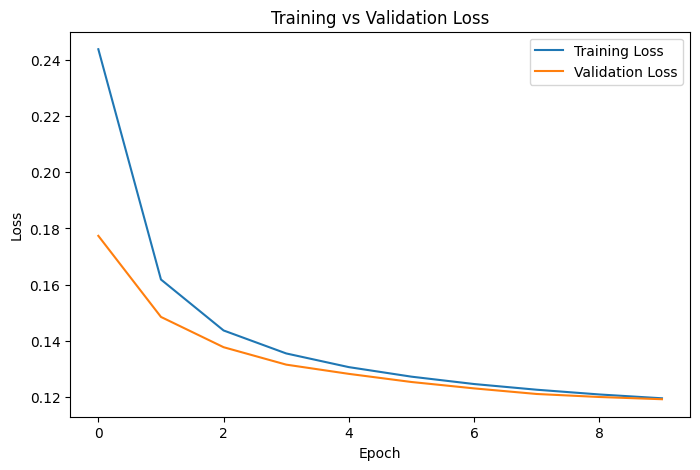

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [28]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
decoded_imgs = decoded_imgs.reshape((-1,28,28))

x_test = x_test.reshape((-1,28,28))
x_test_noisy = x_test_noisy.reshape((-1,28,28))

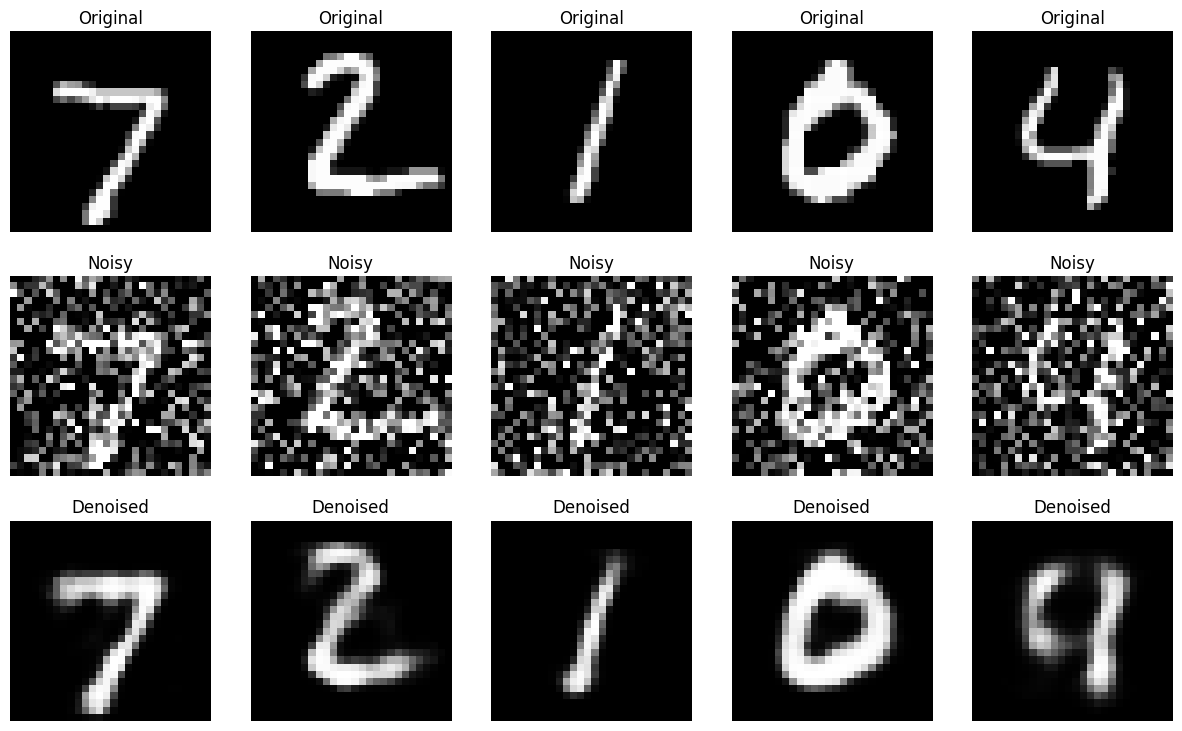

In [30]:
n = 5

plt.figure(figsize=(15,9))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()